In [1]:
import sys
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

In [2]:
from relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx # type: ignore[reportMissingImports]
from relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from testers.classical_solve_lin_program import solve_lp # type: ignore[reportMissingImports]
from testers.classical_solve_quad_program import solve_qcp # type: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np

true_false = (True, False)

This notebook is for experimenting on with linear approximations to the toy problem or the GasNet-11 problem.

You can download the relevant GasNet-11 files from Sergey's emails.

Some conclusions:
- The condition number is stable with the bound constraints for the toy problem but goes to infinity without them (is there an eigenvalue of 0?)
- The condition number is a bit higher in general for the real problem but still manageable without the bound constraints.
- Most bound constraint parameters to the linear approximation don't affect the condition number. Some (N, lambda) are hard to check because the toy problem seems to have odd properties compared to the real problem. The condition number is linearly proportional to the number of linear constraints. The effect of if the coefficient is included in the surrogate is large and very different depending on toy vs. real.

In [3]:
# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = True

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = False

In [4]:
# Put the original QCP into gurobi
qcp_value, qcp_time = solve_qcp(f_name="model11_quad_reform_2.json")
print(qcp_value, qcp_time)

Set parameter Username
Set parameter LicenseID to value 2823041
Academic license - for non-commercial use only - expires 2027-05-16
4692.145737713451 0.015000104904174805


In [5]:
print(solve_lp(f_name="Model11_lp.json"))
print(solve_qcp(f_name="Model11_lp.json"))

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Presolve a model with 93 rows, 21 columns and 258 nonzeros (Min)
Model fingerprint: 0xc13d8e31
Model has 10 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 5e+01]
  Objective range  [1e+00, 2e+00]
  Bounds range     [5e+01, 5e+03]
  RHS range        [8e+01, 3e+04]
Presolve removed 76 rows and 15 columns
Statistics for model 'lp_from_json_pre':
  Problem type                : LP
  Linear constraint matrix    : 17 rows, 6 columns, 46 nonzeros
  Variable types              : 6 continuous, 0 integer (0 binary)
  Matrix range                : [6e-01, 3e+01]
  Objective range             : [8e-01, 1e+00]
  Bounds range                : [2e+02, 5e+03]
  RHS range                   : [6e+01, 3e+03]
Gurobi Opt


CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 93 rows, 21 columns and 258 nonzeros (Min)
Model fingerprint: 0xc13d8e31
Model has 10 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 5e+01]
  Objective range  [1e+00, 2e+00]
  Bounds range     [5e+01, 5e+03]
  RHS range        [8e+01, 3e+04]

Presolve removed 76 rows and 15 columns
Presolve time: 0.01s
Presolved: 17 rows, 6 columns, 46 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.8708515e+03   1.035696e+03   0.000000e+00      0s
       6    4.5879296e+03   0.000000e+00   0.000000e+00      0s

Solved in 6 iterations and 0.02 seconds (0.00 work units)
Optimal objective  4.587929636e+03
(4587.929636019629, 0.01699995994567871)
(4587.929636019691, 0.0009999275207519531)


-0.012132043216297461
-0.833908133573459


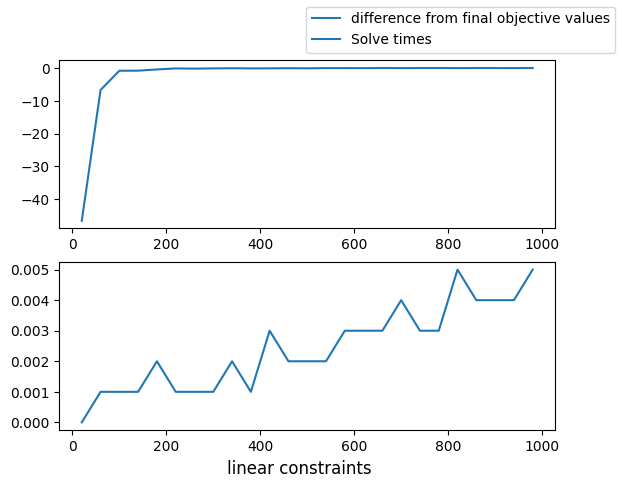

In [13]:
errors = []
times = []

# Model may be infeasible if this is not big enough
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)

for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, endpoints=False,
    #                             f_name="model11_quad_reform_2.json", remove_division=REMOVE_DIVISION)
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, endpoints=True,
                                        f_name="model11_quad_reform_2.json", remove_division=REMOVE_DIVISION)
    val, time = solve_lp()
    if qcp_value is not None and val is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("linear constraints")
ax1.plot(lin_cons_range, errors, label="difference from final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-7.122871828055395
-679.3143998450951


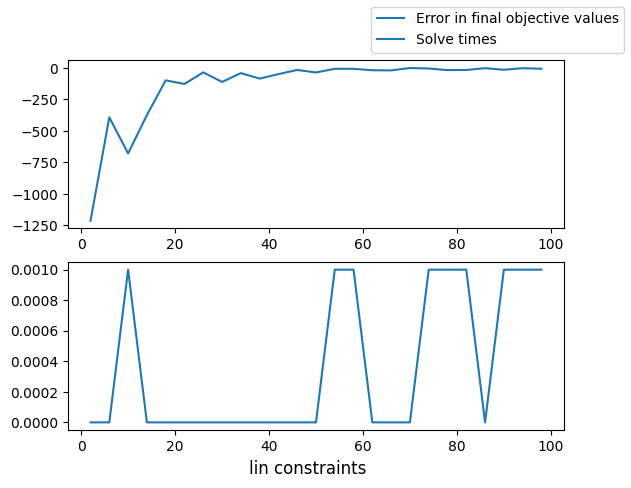

In [42]:
# Tends to be infeasible for inner approximation
if OUTER_APPROXIMATION:
    rng = np.random.default_rng()

    errors = []
    times = []
    lin_cons_range = range(2, 101, 4)
    # lin_cons_range = range(20, 1001, 40)
    for lin_cons in lin_cons_range:
        quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                    SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                    points_function=rng.uniform, remove_division=REMOVE_DIVISION,
                                    f_name="model11_quad_reform_2.json")
        # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
        #                                     points_function=rng.uniform, remove_division=REMOVE_DIVISION,
        #                                     f_name="model11_quad_reform_2.json")
        val, time = solve_lp()
        if val is not None and qcp_value is not None:
            errors.append(val - qcp_value)
            times.append(time)

    fig, (ax1, ax2) = plt.subplots(2, 1)
    fig.supxlabel("lin constraints")
    ax1.plot(lin_cons_range, errors, label="Error in final objective values")
    ax2.plot(lin_cons_range, times, label="Solve times")
    fig.legend()

    print(errors[-1])
    print(errors[2])

In [43]:
concat = 1.67

def np_uniform_bunch_low(lower: float, upper: float, num: int):
    return np.linspace(lower, lower + ((upper - lower)/concat), num)

def np_uniform_bunch_high(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / concat), upper, num)

def np_uniform_bunch_middle(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / (2*concat)), lower + ((upper - lower)/(2*concat)), num)

-0.6545482260489734
-45.263500889151146


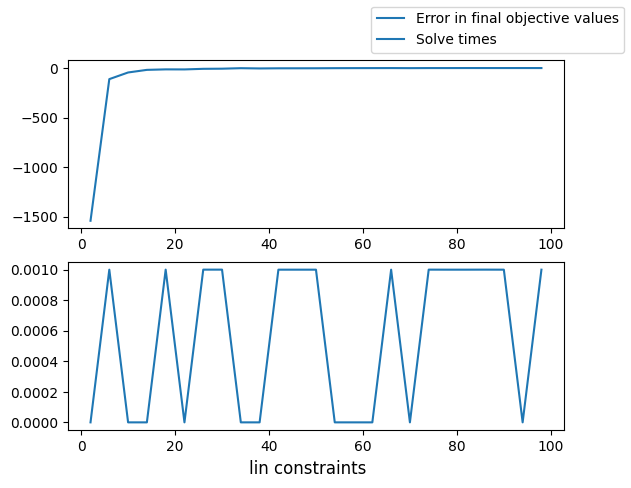

In [44]:
errors = []
times = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_2.json")
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-1541.5870024185542
-1541.5870024185542


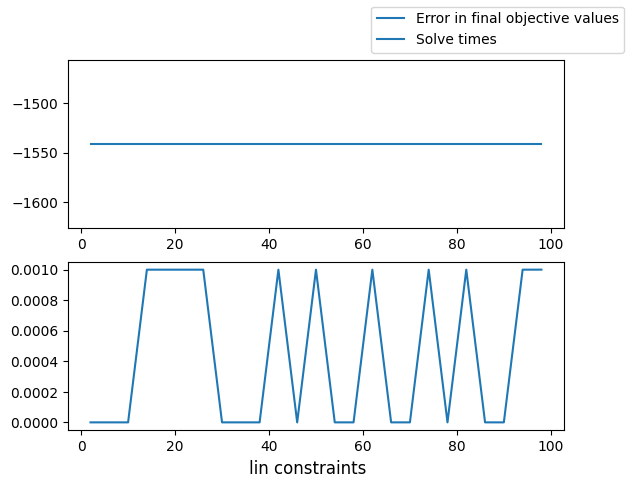

In [45]:
errors = []
times = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_2.json")
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-1541.5870024185542
-1541.5870024185542


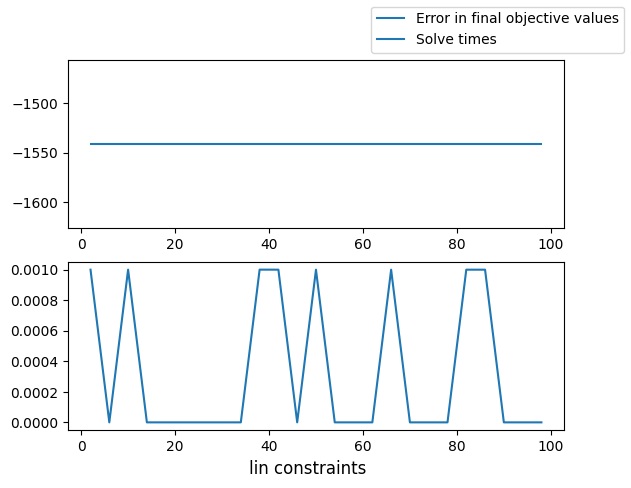

In [46]:
errors = []
times = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_2.json")
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

1.6338677354709419


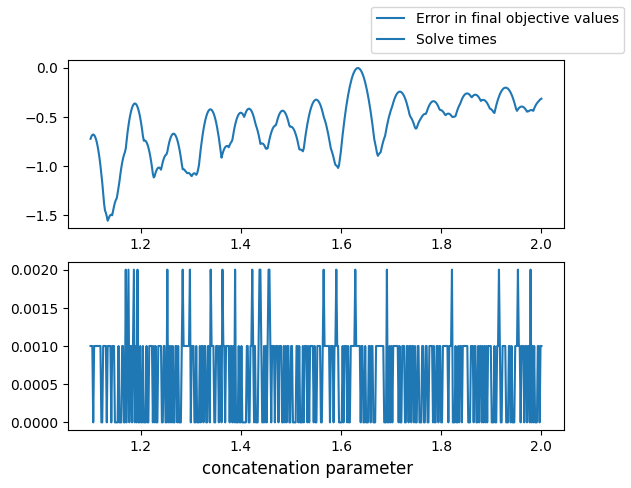

In [14]:
points = np.linspace(1.1, 2, 500, endpoint=True)
LIN_CONSTRAINTS = 100

errors = []
times = []
for concat in points:
    
    def np_uniform_bunch_low(lower: float, upper: float, num: int):
        return np.linspace(lower, lower + ((upper - lower)/concat), num)

    
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, endpoints=False,
                                points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_2.json")
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("concatenation parameter")
ax1.plot(points, errors, label="Error in final objective values")
ax2.plot(points, times, label="Solve times")
fig.legend()

print(points[np.argmin(np.abs(errors))])